In [31]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

In [32]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(
        os.path.join("dataset", sub_folder)
    )

    for filename in sub_folder_files:

        img_path = os.path.join(
            "dataset",
            sub_folder,
            filename
        )

        img = cv.imread(img_path)

        if img is None:
            print(f"Gagal membaca: {img_path}")
            continue

        img = img.astype(np.uint8)

        # grayscale
        img = cv.cvtColor(
            img,
            cv.COLOR_BGR2GRAY
        )

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data, dtype=object)
labels = np.array(labels)

In [33]:
print(f"Jumlah data asli : {len(data)}")

Jumlah data asli : 840


## Visualisasi Sebelum Preprocessing 1

In [ ]:
plt.figure(figsize=(12, 3))

unique_labels = np.unique(labels)

for i, kelas in enumerate(unique_labels):

    idx = np.where(labels == kelas)[0][0]

    plt.subplot(1, 4, i + 1)
    plt.imshow(data[idx], cmap="gray")
    plt.title(kelas)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Augmentation

In [ ]:
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):

    img = data[i]
    label = labels[i]
    fname = file_name[i]

    name, ext = os.path.splitext(fname)

    # gambar asli
    data_augmented.append(img)
    labels_augmented.append(label)
    file_name_augmented.append(fname)

    # flip horizontal
    flip_h = cv.flip(img, 1)
    data_augmented.append(flip_h)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_flipH" + ext
    )

    # flip vertikal
    flip_v = cv.flip(img, 0)
    data_augmented.append(flip_v)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_flipV" + ext
    )

    # rotasi 90 derajat
    rot_90 = cv.rotate(
        img,
        cv.ROTATE_90_CLOCKWISE
    )
    data_augmented.append(rot_90)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_rot90" + ext
    )

data_augmented = np.array(
    data_augmented,
    dtype=object
)

labels_augmented = np.array(
    labels_augmented
)

In [35]:
print("Data sebelum augmentasi :", len(data))
print("Data setelah augmentasi :", len(data_augmented))

Data sebelum augmentasi : 840
Data setelah augmentasi : 3360


## Data Preparation

### Grayscale + Resize + Normalisasi

In [36]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros((new_height, new_width),
                             dtype=np.uint8)

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

In [37]:
def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape, dtype=np.uint8)
    return (
        (image - min_val) /
        (max_val - min_val) * 255
    ).astype(np.uint8)

In [38]:
def prepro1(image):
    image = resize(image, 224, 224)
    image = normalisasi(image)

    return image

In [39]:
data_preprocessed = []

for i in range(len(data_augmented)):
    img = prepro1(data_augmented[i])
    data_preprocessed.append(img)

data_preprocessed = np.array(
    data_preprocessed,
    dtype=np.uint8
)

In [40]:
print(data_preprocessed.shape)

(3360, 224, 224)


## Visualisasi Hasil Preprocessing 1

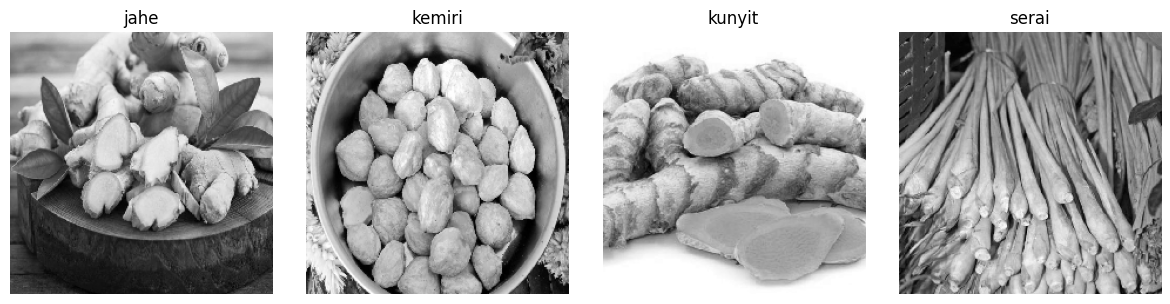

In [44]:
plt.figure(figsize=(12, 3))

unique_labels = np.unique(labels)

for i, kelas in enumerate(unique_labels):

    # cari gambar pertama dari kelas tersebut
    idx = np.where(labels == kelas)[0][0]

    # hasil preprocessing
    img = prepro1(data[idx])

    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(kelas)
    plt.axis("off")

plt.tight_layout()
plt.show()